# 트랜스 포머 블럭 만들기

In [41]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import math

In [42]:
from transformers import AutoModel
BERT_model = AutoModel.from_pretrained("klue/bert-base")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2405.54it/s]
[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
BERT_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(32000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [44]:
class 블록(nn.Module):
    def __init__(self, d, d_ff, h):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.norm1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(
            nn.Linear(d, d_ff),
            nn.GELU(),   #활성화함수, ReLU 대신
            nn.Linear(d_ff, d)
        )
        self.norm2 = nn.LayerNorm(d)

    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x = self.norm1(x + a)
        f = self.ffn(x)
        x = self.norm2(x + f)
        return x

In [45]:
import block
import koplot

In [46]:
layer_0 = block.bert_layer0(BERT_model)

In [47]:
설정값 = BERT_model.config
설정값

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.14.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 32000
}

In [48]:
문장 = [ "나는", "밥을", "먹었다", "."]
d = 8
x = torch.rand(len(문장), d)

In [49]:
a = block.SelfAttention(d)
out, _ = a(x)

In [50]:
# 순서 정보 섞기
# 밥을 나는 . 먹었다 <-
idx = [1, 0, 3, 2]

In [51]:
idx = [1, 0, 3, 2]      # 순서 섞기
x_r = x[idx]            # 입력 순서 변경

out_r, _ = a(x_r)

In [52]:
out

tensor([[ 0.0072,  0.0972, -0.0574, -0.1019, -0.2453,  0.1405, -0.1093, -0.1613],
        [ 0.0080,  0.0965, -0.0573, -0.1020, -0.2443,  0.1410, -0.1102, -0.1600],
        [ 0.0074,  0.0973, -0.0567, -0.1023, -0.2461,  0.1393, -0.1087, -0.1616],
        [ 0.0087,  0.0955, -0.0582, -0.1010, -0.2428,  0.1420, -0.1112, -0.1580]],
       grad_fn=<MmBackward0>)

In [53]:
out_r

tensor([[ 0.0080,  0.0965, -0.0573, -0.1020, -0.2443,  0.1410, -0.1102, -0.1600],
        [ 0.0072,  0.0972, -0.0574, -0.1019, -0.2453,  0.1405, -0.1093, -0.1613],
        [ 0.0087,  0.0955, -0.0582, -0.1010, -0.2428,  0.1420, -0.1112, -0.1580],
        [ 0.0074,  0.0973, -0.0567, -0.1023, -0.2461,  0.1393, -0.1087, -0.1616]],
       grad_fn=<MmBackward0>)

In [54]:
out[0] == out_r[1]

tensor([True, True, True, True, True, True, True, True])

In [55]:
out[3] == out_r[2]

tensor([True, True, True, True, True, True, True, True])

In [56]:
PE = block.sinusoidal_pe(512, 768)
block.sinusoidal_pe(4, 8)

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])

In [57]:
PE.min(), PE.max()

(tensor(-1.), tensor(1.))

In [58]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

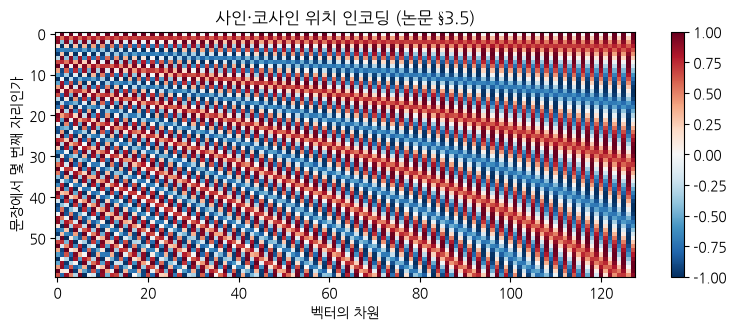

In [59]:
자리수, 차원수 = 60, 128        # 다 그리면 너무 커서 앞부분만 본다

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(PE[:자리수, :차원수], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("벡터의 차원")
ax.set_ylabel("문장에서 몇 번째 자리인가")
ax.set_title("사인·코사인 위치 인코딩 (논문 §3.5)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [60]:
학습된PE = BERT_model.embeddings.position_embeddings.weight.detach()

In [61]:
학습된PE.min()

tensor(-0.5147)

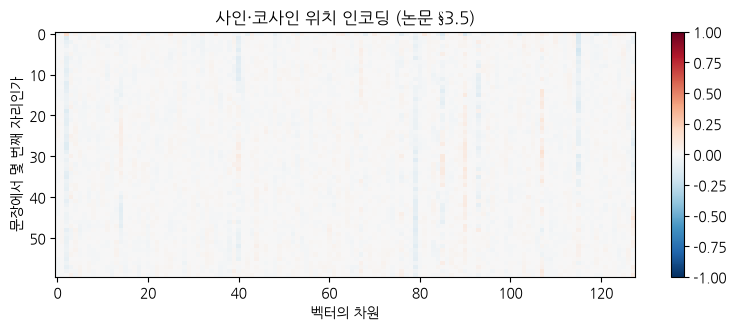

In [62]:
자리수, 차원수 = 60, 128        # 다 그리면 너무 커서 앞부분만 본다

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(학습된PE[:자리수, :차원수], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("벡터의 차원")
ax.set_ylabel("문장에서 몇 번째 자리인가")
ax.set_title("사인·코사인 위치 인코딩 (논문 §3.5)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [63]:
사인유사도 = block.neighbor_similarity(PE)

In [64]:
학습유사도 = block.neighbor_similarity(학습된PE)


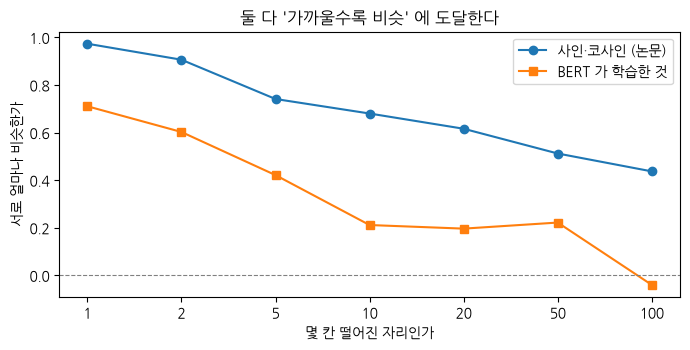

In [65]:
fig, ax = plt.subplots(figsize=(7, 3.6))
칸 = list(사인유사도.keys())
자리 = range(len(칸))                       # 눈금을 고르게 — 로그축을 쓰지 않는다
ax.plot(자리, [사인유사도[k] for k in 칸], marker="o", label="사인·코사인 (논문)")
ax.plot(자리, [학습유사도[k] for k in 칸], marker="s", label="BERT 가 학습한 것")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xticks(list(자리))
ax.set_xticklabels([str(k) for k in 칸])
ax.set_xlabel("몇 칸 떨어진 자리인가")
ax.set_ylabel("서로 얼마나 비슷한가")
ax.set_title("둘 다 '가까울수록 비슷' 에 도달한다")
ax.legend()
plt.tight_layout()
plt.show()

[koplot] 한글 폰트 적용: NanumGothic


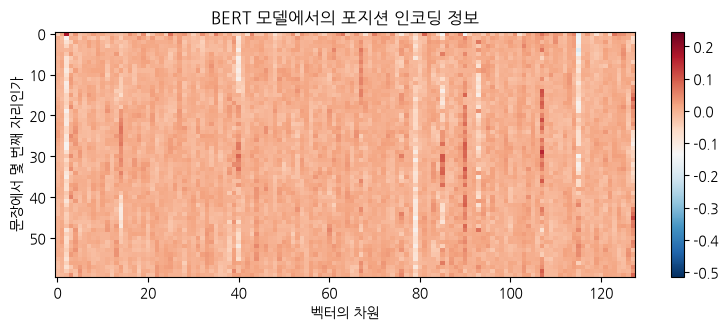

In [66]:
# 위치 인코딩 시각화
koplot.use_korean()

자리수, 차원수 = 60, 128        # 다 그리면 너무 커서 앞부분만 본다

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(학습된PE[:자리수, :차원수], aspect="auto", cmap="RdBu_r", vmin=-0.5147, vmax=0.2457)
ax.set_xlabel("벡터의 차원")
ax.set_ylabel("문장에서 몇 번째 자리인가")
ax.set_title("BERT 모델에서의 포지션 인코딩 정보")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
# 벡터 공간의 지문을 통해 위치 정보에 대한 벡터를 가지게 된다.

In [67]:
깊이 = 12
x0 = torch.randn(1, 6, 8)
x_그냥 = x0.clone()
x_잔차 = x0.clone()
x_LN = x0.clone()
층들 = [ block.SelfAttention(8) for _ in range(깊이 )]

In [68]:
# 잔차가 없이, 그냥 여러겹 쌓으면, 벡터 정보 신호의 크기가 사라져간다. 층을 통과할수록
크기_그냥 = []

for 층 in 층들:
    x_그냥, _ = 층(x_그냥)
    크기_그냥.append( x_그냥.norm().item() )
크기_그냥

[1.2789472341537476,
 0.49379798769950867,
 0.1917925775051117,
 0.06502904742956161,
 0.01909467577934265,
 0.0034979847259819508,
 0.0011559759732335806,
 0.0001857222814578563,
 5.1508162869140506e-05,
 1.6970661818049848e-05,
 6.579170985787641e-06,
 2.7743956252379576e-06]

In [69]:
# 잔차를 추가하면, 신호가 사라지는 대신, 신호가 남고 쌓여간다.
크기_잔차 = []

for 층 in 층들:             # 12개의 층 통과
    서브, _ = 층(x_잔차)
    x_잔차 = x_잔차 + 서브     # 값을 그냥 대입하는 게 아니라, 잔차를 더해주는 방식
    크기_잔차.append( x_잔차.norm().item() )
크기_잔차

[7.436480522155762,
 7.521431922912598,
 7.713273525238037,
 7.904260158538818,
 7.600725173950195,
 7.7889723777771,
 7.703620910644531,
 8.03768539428711,
 8.017215728759766,
 8.130367279052734,
 8.294746398925781,
 8.377464294433594]

In [70]:
정규화층들 = [ nn.LayerNorm(8) for _ in range(12) ]  # 12개의 정규화층

크기_LN = []

for 층, 정규화 in zip(층들, 정규화층들):             # 12개의 층 통과
    서브, _ = 층(x_LN)
    x_LN = 정규화(x_LN + 서브)     # 전차를 더해준 값을 정규화 층을 통과시켜줌.
    크기_LN.append( x_LN.norm().item() )
크기_LN

[6.928171157836914,
 6.928168296813965,
 6.928167343139648,
 6.928169250488281,
 6.928166389465332,
 6.928167819976807,
 6.928167343139648,
 6.928170680999756,
 6.928167343139648,
 6.9281697273254395,
 6.9281697273254395,
 6.928169250488281]

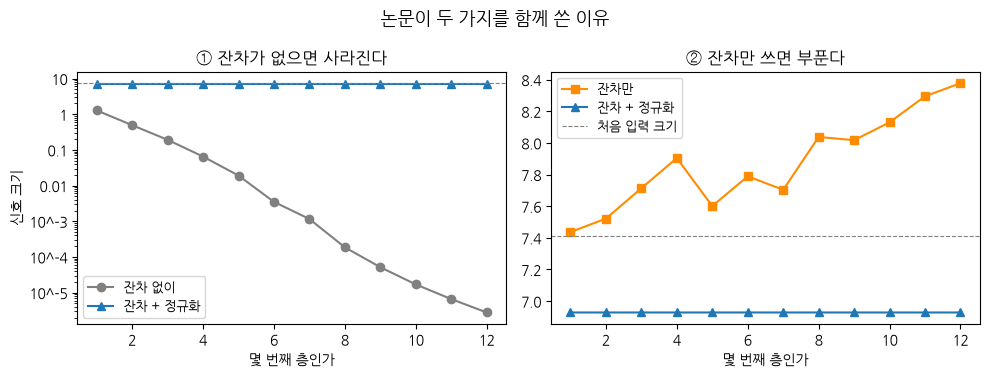

In [71]:
# 두 이야기를 한 그림에 겹치면 안 된다 — 로그축 하나에 셋을 얹으면
# "부푼다" 쪽이 직선처럼 눌려 안 보인다. 그래서 나눠 그린다.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
층번호 = list(range(1, 깊이 + 1))
처음 = x0.norm().item()

axes[0].plot(층번호, 크기_그냥, marker="o", color="gray", label="잔차 없이")
axes[0].plot(층번호, 크기_LN, marker="^", label="잔차 + 정규화")
axes[0].axhline(처음, color="gray", ls="--", lw=0.8)
axes[0].set_yscale("log")
koplot.ascii_log_axis(axes[0], "y")
axes[0].set_title("① 잔차가 없으면 사라진다")
axes[0].set_ylabel("신호 크기")

axes[1].plot(층번호, 크기_잔차, marker="s", color="darkorange", label="잔차만")
axes[1].plot(층번호, 크기_LN, marker="^", label="잔차 + 정규화")
axes[1].axhline(처음, color="gray", ls="--", lw=0.8, label="처음 입력 크기")
axes[1].set_title("② 잔차만 쓰면 부푼다")

for ax in axes:
    ax.set_xlabel("몇 번째 층인가")
    ax.legend(fontsize=9)
fig.suptitle("논문이 두 가지를 함께 쓴 이유", fontsize=13)
plt.tight_layout()
plt.show()


In [72]:
# FFN =
# 입력 차원 => 차원을 증가 768 증가 * 4 = 3072 => 768
# 넓게 펼쳐서 적절하게 골라서. 다시 원래 크기로 접는다.
d = 768
d_ff = 3072
내FFN = nn.Sequential(
    nn.Linear(d, d_ff),
    nn.GELU(),
    nn.Linear(d_ff, d),
)

In [73]:
# 가중치를 같은 가중치 사용하지만, 각 자리끼리는 섞이지 않는다.
# 다른 신경망을 사용하는 것이 안다.
sample = torch.randn(1, 4, d)
내FFN(sample[0, 1])
내FFN(sample)[0][1]

tensor([ 1.8240e-01,  1.7738e-01,  1.2944e-01, -5.5477e-03,  6.5623e-02,
         7.6468e-02,  7.9391e-02,  8.1461e-02, -1.6482e-02, -3.0504e-02,
        -6.0028e-02, -1.7385e-01,  9.8584e-02, -2.2495e-01,  3.9951e-02,
        -3.8333e-03, -8.3940e-02, -1.2548e-01,  2.4735e-02, -2.5446e-02,
         1.4469e-02,  3.8390e-02,  3.3323e-03, -1.7733e-01, -1.4029e-01,
        -4.5676e-02, -8.4190e-02,  3.8345e-01,  2.4981e-01, -1.9332e-01,
        -3.6956e-02, -1.6664e-01,  3.6914e-01,  1.9269e-01,  1.7528e-01,
         1.2711e-01, -3.2548e-01, -2.4216e-01,  1.8626e-01,  3.7064e-01,
        -3.1374e-01,  1.9329e-01,  4.7729e-02, -2.2502e-01,  3.2776e-01,
         4.8099e-01, -2.3101e-01,  9.1281e-02, -3.3770e-01, -7.8228e-02,
        -4.2486e-02,  2.5311e-01, -1.7145e-01, -5.1567e-02,  2.7230e-01,
        -2.9578e-01, -3.0705e-01,  2.4919e-01, -2.8836e-02,  3.2582e-01,
        -1.7843e-01, -2.4003e-01, -2.9861e-01, -6.7319e-03, -2.4288e-01,
        -2.1370e-01,  2.4953e-01,  2.6277e-01, -3.1

In [74]:
d = 설정값.hidden_size
d_ff = 설정값.intermediate_size
h = 설정값.num_attention_heads

print(d, d_ff, h)
내블록 = block.내블록(d, d_ff, h=12)
내블록

768 3072 12


내블록(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (ffn): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
)

In [75]:
print(f"파라미터수 : {block.n_params(내블록):,}")
layer_0 = BERT_model.encoder.layer[0]

파라미터수 : 7,087,872


In [76]:

layer_0 = BERT_model.encoder.layer[0]
print(f"파라미터수 : {block.n_params(layer_0):,}")

파라미터수 : 7,087,872


In [77]:
토치블록 = nn.TransformerEncoderLayer(d_model=d, nhead=h, dim_feedforward=d_ff, batch_first=True)
print(f"파라미터 수 : {block.n_params(토치블록):,}" )

파라미터 수 : 7,087,872


In [78]:
# 파라미터 크기는 같지만, 내부 구조 이름들은 다름.
[ n for n, _ in 내블록.named_children() ]
[ n for n, _ in layer_0.named_children() ]
[ n for n, _ in 토치블록.named_children() ]


['self_attn',
 'linear1',
 'dropout',
 'linear2',
 'norm1',
 'norm2',
 'dropout1',
 'dropout2']

In [79]:
d = 설정값.hidden_size
d_ff = 설정값.intermediate_size

attention_p = 4 * (d * d + d) # 4인 이유 Q, V, K, O 가중치 + 편향
ffn_p = (d * d_ff + d_ff) + (d_ff * d + d)
layer_norm_p = 2 * (2 * d)
attention_p + ffn_p + layer_norm_p == block.n_params(layer_0)

False

In [80]:
(attention_p + ffn_p + layer_norm_p) * 24

113467392